# Time series workflow by Benson Kachappilly
#### The following workflow seeks to answer the following question: Are RNNs useful in predicting the amount of electricity (in GWh) of Nuclear, based on the production of Nuclear, Hydro, Natural Gas, Solar, Wind over a 5-year period

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os
import keras
import seaborn as sns
from keras.src.losses import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [60]:
# Uses GPU memory as required
config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
session = tf.compat.v1.InteractiveSession(config=config)

ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


I0000 00:00:1745573400.220733  189360 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6136 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:09:00.0, compute capability: 7.5


In [61]:
# Prints the current working directory
cwd = os.getcwd()
print(cwd)

/home/benson/DataspellProjects/Data_Science/Deep Learning/Assessment/Assessment 2 Time_series_workflow


In [62]:
# Developed from subject COSC102 Data Science Studio 1
def load_data(dataset_path):
    """Function load_data loads the dataset and returns it as a pandas dataframe.

        Arguments:
            dataset_path -- Path to the dataset folder.

        Returns:
            pandas dataframe -- The dataset as a pandas dataframe.

    """


    return pd.read_csv(dataset_path)

#### The dataset used is the Global Electricity Production dataset.
#### https://www.kaggle.com/datasets/sazidthe1/global-electricity-production/data

In [63]:
dataset_path = ("global_electricity_production_data.csv")

In [64]:
print(load_data(dataset_path))

         country_name       date                       parameter  \
0           Australia  12/1/2023      Net Electricity Production   
1           Australia  12/1/2023      Net Electricity Production   
2           Australia  12/1/2023      Net Electricity Production   
3           Australia  12/1/2023      Net Electricity Production   
4           Australia  12/1/2023      Net Electricity Production   
...               ...        ...                             ...   
121069  United States   1/1/2010                   Total Imports   
121070  United States   1/1/2010                   Total Exports   
121071  United States   1/1/2010         Used for pumped storage   
121072  United States   1/1/2010             Distribution Losses   
121073  United States   1/1/2010  Final Consumption (Calculated)   

                                  product        value unit  
0                             Electricity   22646.1901  GWh  
1                 Total Combustible Fuels   13397.9356  GWh

In [65]:
electricity_production = load_data(dataset_path)

In [66]:
# Shows the first few rows of the electricity_production data
electricity_production.head()

,country_name,date,parameter,product,value,unit
0,Australia,12/1/2023,Net Electricity Production,Electricity,22646.1901,GWh
1,Australia,12/1/2023,Net Electricity Production,Total Combustible Fuels,13397.9356,GWh
2,Australia,12/1/2023,Net Electricity Production,"Coal, Peat and Manufactured Gases",9768.5223,GWh
3,Australia,12/1/2023,Net Electricity Production,Oil and Petroleum Products,289.5415,GWh
4,Australia,12/1/2023,Net Electricity Production,Natural Gas,3091.9272,GWh


In [67]:
# Shows the last few rows of the electricity_production data
electricity_production.info

<bound method DataFrame.info of          country_name       date                       parameter  \
0           Australia  12/1/2023      Net Electricity Production   
1           Australia  12/1/2023      Net Electricity Production   
2           Australia  12/1/2023      Net Electricity Production   
3           Australia  12/1/2023      Net Electricity Production   
4           Australia  12/1/2023      Net Electricity Production   
...               ...        ...                             ...   
121069  United States   1/1/2010                   Total Imports   
121070  United States   1/1/2010                   Total Exports   
121071  United States   1/1/2010         Used for pumped storage   
121072  United States   1/1/2010             Distribution Losses   
121073  United States   1/1/2010  Final Consumption (Calculated)   

                                  product        value unit  
0                             Electricity   22646.1901  GWh  
1                 Total Com

In [68]:
# Shows the number of rows and columns in the electricity_production data
electricity_production.describe()

,value
count,121060.00000
mean,6925.08149
std,34224.45546
min,0.00000
25%,41.19900
50%,470.41900
75%,2629.71275
max,865976.48280


In [69]:
# Developed from subject COSC102 Data Science Studio 1
def check_NaN(dataframe):
    """Function check_NaN checks if the dataframe contains NaN values.

        Arguments:
            dataframe -- The dataframe to be checked.

        Returns:

    """

    print("Total NaN: ", dataframe.isnull().values.sum())
    print("NaN by columns:\n", dataframe.isnull().sum)
    return


In [70]:
check_NaN(electricity_production)

Total NaN:  14
NaN by columns:
 <bound method DataFrame.sum of         country_name   date  parameter  product  value   unit
0              False  False      False    False  False  False
1              False  False      False    False  False  False
2              False  False      False    False  False  False
3              False  False      False    False  False  False
4              False  False      False    False  False  False
...              ...    ...        ...      ...    ...    ...
121069         False  False      False    False  False  False
121070         False  False      False    False  False  False
121071         False  False      False    False  False  False
121072         False  False      False    False  False  False
121073         False  False      False    False  False  False

[121074 rows x 6 columns]>


#### Upon closer inspection of the Null values, it is a comment that states for a particular country the data is estimated for that month. We can remove all instances of this from the electricity_production dataset.

In [71]:
electricity_production = electricity_production.dropna()

In [72]:
check_NaN(electricity_production)

Total NaN:  0
NaN by columns:
 <bound method DataFrame.sum of         country_name   date  parameter  product  value   unit
0              False  False      False    False  False  False
1              False  False      False    False  False  False
2              False  False      False    False  False  False
3              False  False      False    False  False  False
4              False  False      False    False  False  False
...              ...    ...        ...      ...    ...    ...
121069         False  False      False    False  False  False
121070         False  False      False    False  False  False
121071         False  False      False    False  False  False
121072         False  False      False    False  False  False
121073         False  False      False    False  False  False

[121060 rows x 6 columns]>


In [73]:
# Shows the unique values of the country_name
pd.Series(electricity_production["country_name"].unique())

0           Australia
1             Austria
2             Belgium
3              Canada
4               Chile
5            Colombia
6          Costa Rica
7      Czech Republic
8             Denmark
9             Estonia
10            Finland
11             France
12            Germany
13             Greece
14            Hungary
15            Iceland
16            Ireland
17              Italy
18              Japan
19              Korea
20             Latvia
21          Lithuania
22         Luxembourg
23             Mexico
24        Netherlands
25        New Zealand
26             Norway
27             Poland
28           Portugal
29    Slovak Republic
30           Slovenia
31              Spain
32             Sweden
33        Switzerland
34             Turkey
35     United Kingdom
36      United States
37          Argentina
38             Brazil
39           Bulgaria
40              China
41            Croatia
42             Cyprus
43              India
44              Malta
45    Nort

In [74]:
# Shows the unique values of the parameter
pd.Series(electricity_production["parameter"].unique())

0        Net Electricity Production
1           Used for pumped storage
2               Distribution Losses
3    Final Consumption (Calculated)
4                     Total Imports
5                     Total Exports
dtype: object

In [75]:
# Shows the unique values of the product
pd.Series(electricity_production["product"].unique())

0                                           Electricity
1                               Total Combustible Fuels
2                     Coal, Peat and Manufactured Gases
3                            Oil and Petroleum Products
4                                           Natural Gas
5                                Combustible Renewables
6                                                 Hydro
7                                                  Wind
8                                                 Solar
9     Total Renewables (Hydro, Geo, Solar, Wind, Other)
10                     Other Combustible Non-Renewables
11                                           Geothermal
12                                        Not Specified
13                                              Nuclear
14                                     Other Renewables
dtype: object

#### Our electricity_production dataset contains a lot of information that is not necessary in answering our research question. We will begin to remove this information and cleanup up our dataset.
#### Firstly we will remove the units columns as this will not be a useful attribute for our workflow. We are only looking at the production of electricity products, which are showcased as Net Electricity Products. However, other rows in the parameter attribute include: those used for pumped storage, Distribution Losses, Final Consumption, Total Imports, and Total exports. This is considered unimportant, and we will look to remove these rows.
#### Secondly, the product attribute reveals combined information about our electricity products such as Total Combustible Fuels, Combustible Renewables, Total Renewables, Other Combustible Non-Renewables, Not Specified, Other Renewables. This is considered unimportant, and we will look to remove these rows.

In [76]:
electricity_production = electricity_production.drop(columns="unit")

In [77]:
electricity_production.head()

,country_name,date,parameter,product,value
0,Australia,12/1/2023,Net Electricity Production,Electricity,22646.1901
1,Australia,12/1/2023,Net Electricity Production,Total Combustible Fuels,13397.9356
2,Australia,12/1/2023,Net Electricity Production,"Coal, Peat and Manufactured Gases",9768.5223
3,Australia,12/1/2023,Net Electricity Production,Oil and Petroleum Products,289.5415
4,Australia,12/1/2023,Net Electricity Production,Natural Gas,3091.9272


In [78]:
# Developed with the assistance of AI, where I have only kept the net electricity production and the products of interest.
chosen_parameter = "Net Electricity Production"
chosen_products = ["Coal, Peat and Manufactured Gases", "Oil and Petroleum Products", "Natural Gas", "Hydro", "Wind", "Solar", "Geothermal", "Nuclear"]

filtered_electricity_production = electricity_production[(electricity_production["parameter"] == chosen_parameter) &
                                                         (electricity_production["product"].isin(chosen_products))]
filtered_electricity_production.to_csv("filtered_global_electricity_production_data.csv", index=False)

In [79]:
dataset_path = ("filtered_global_electricity_production_data.csv")
filtered_electricity_production = load_data(dataset_path)

In [80]:
pd.Series(filtered_electricity_production["parameter"].unique())

0    Net Electricity Production
dtype: object

In [81]:
pd.Series(filtered_electricity_production["product"].unique())

0    Coal, Peat and Manufactured Gases
1           Oil and Petroleum Products
2                          Natural Gas
3                                Hydro
4                                 Wind
5                                Solar
6                           Geothermal
7                              Nuclear
dtype: object

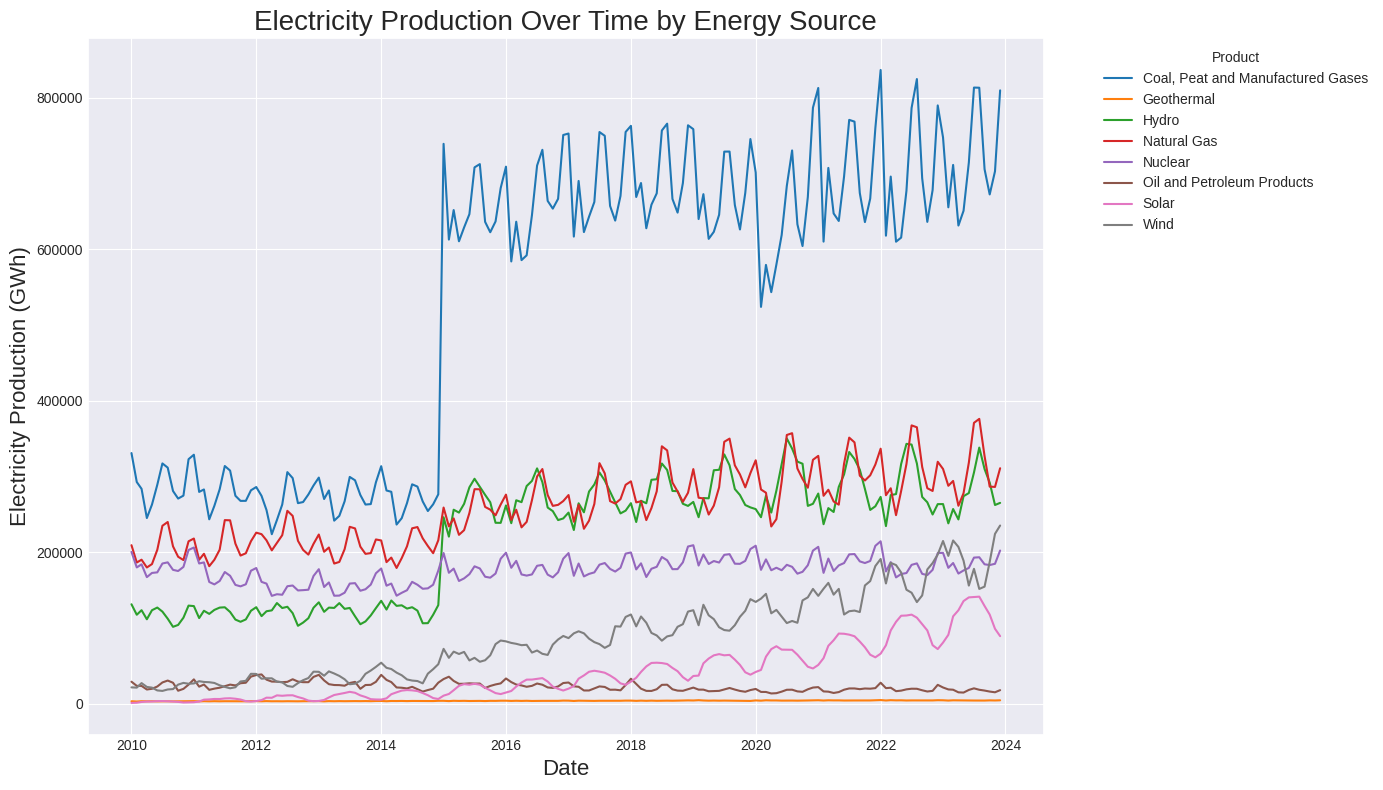

In [82]:
# Developed with the assistance of AI to create the aggregated data for the filtered_electricity_production based on the date and product
filtered_electricity_production["date"] = pd.to_datetime(filtered_electricity_production["date"])
grouped_date_product = filtered_electricity_production.groupby(["date", "product"])["value"].sum().unstack()
plt.figure(figsize=(14, 8), facecolor='w', edgecolor='k')
for product in grouped_date_product.columns:
    plt.plot(grouped_date_product.index, grouped_date_product[product], label=product)

# Developed with the assistance of AI to plot the electricity production over time by energy source
plt.title("Electricity Production Over Time by Energy Source", fontsize=20)
plt.style.use("seaborn-v0_8-white")
plt.xlabel("Date", fontsize=16)
plt.ylabel("Electricity Production (GWh)", fontsize=16)
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

#### The electricity production over time by energy source graph highlights the electricity production over the course of 2010-2023 for each energy product types, the electricity production is aggregated from each country and demonstrates the total amount for each product.

#### Of the 8 products we have in our dataset, we will only train 5 of these products, this will be: Nuclear, Hydro, Natural Gas, Solar, and Wind. For our workflow we will predict Nuclear, and use a time-series sequence length of 5 years. Starting from 2018-2022 using training data, and predicting Nuclear on 2023.

In [83]:
# Developed with the assistance of AI to filter the dataset to only include the selected products and the years 2018-2023
selected_products = ["Nuclear", "Hydro", "Natural Gas", "Solar", "Wind"]
filtered_electricity_production = filtered_electricity_production[filtered_electricity_production["product"].isin(selected_products)]

filtered_electricity_production = filtered_electricity_production[(filtered_electricity_production["date"].dt.year >= 2018) & (filtered_electricity_production["date"].dt.year <= 2023)]

filtered_electricity_production.to_csv("selected_products_2018_2023.csv", index=False)

In [84]:
dataset_path = ("selected_products_2018_2023.csv")
selected_products_2018_2023 = load_data(dataset_path)

#### We will use 10 countries for training, based on varied geolocations, populations, economic statuses and environmental conditions, then apply our trained model on 5 countries for inference.

#### To do this we will have to ensure all 5 products are found in our training dataset and inference set. We will filter for countries that only have these products.

In [85]:
# Developed with the assistance of AI to check if each country has all the selected products
selected_products = {"Nuclear", "Hydro", "Natural Gas", "Solar", "Wind"}

country_product_groups = selected_products_2018_2023.groupby('country_name')['product'].unique()

countries_with_all_products = [
    country for country, products in country_product_groups.items()
    if selected_products.issubset(set(products))]

print("Countries with complete data for all 5 required products:")
print(countries_with_all_products)
print(f"\nTotal countries: {len(countries_with_all_products)}")

Countries with complete data for all 5 required products:
['Argentina', 'Australia', 'Austria', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'India', 'Ireland', 'Italy', 'Japan', 'Korea', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Mexico', 'Netherlands', 'New Zealand', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Serbia', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 'United Kingdom', 'United States']

Total countries: 46


#### This does not seem correct, as upon closer examination of the selected_products_2018_2023 dataset, there are quite a few countries that do not have Nuclear power. Therefore, with 46/48 countries fulfilling our criteria. it does not make sense.

In [86]:
# Check the last 10 rows of the selected_products_2018_2023 dataset
selected_products_2018_2023.tail(10)

,country_name,date,parameter,product,value
16198,North Macedonia,2018-01-01,Net Electricity Production,Solar,1.2131
16199,Peru,2018-01-01,Net Electricity Production,Natural Gas,1185.7103
16200,Peru,2018-01-01,Net Electricity Production,Hydro,3045.0290
16201,Peru,2018-01-01,Net Electricity Production,Wind,86.9666
16202,Peru,2018-01-01,Net Electricity Production,Solar,59.4668
16203,Serbia,2018-01-01,Net Electricity Production,Nuclear,0.0000
16204,Serbia,2018-01-01,Net Electricity Production,Natural Gas,56.4579
16205,Serbia,2018-01-01,Net Electricity Production,Hydro,1191.7860
16206,Serbia,2018-01-01,Net Electricity Production,Wind,8.0899
16207,Serbia,2018-01-01,Net Electricity Production,Solar,0.5130


#### By looking at the end of the selected_products_2018_2023 dataset, Nuclear has a value of 0. Our above identification of countries that have our 5 products of interest would show for most countries even though Nuclear is at 0. We need to remove these rows that have 0 and call the above code again.

In [87]:
# Developed with the assistance of AI to remove rows where the value is 0
selected_products_2018_2023_non_zero = selected_products_2018_2023[selected_products_2018_2023['value'] != 0]

selected_products_2018_2023_non_zero.to_csv("selected_products_2018_2023_non_zero.csv", index=False)


In [88]:
dataset_path = ("selected_products_2018_2023_non_zero.csv")
non_zero_selected_products_2018_2023 = load_data(dataset_path)

In [89]:
# Developed with the assistance of AI to check if each country has all the selected products
selected_products = {"Nuclear", "Hydro", "Natural Gas", "Solar", "Wind"}

country_product_groups = non_zero_selected_products_2018_2023.groupby('country_name')['product'].unique()

countries_with_all_products = [
    country for country, products in country_product_groups.items()
    if selected_products.issubset(set(products))]


print("Countries with complete data for all 5 required products:")
print(countries_with_all_products)
print(f"\nTotal countries: {len(countries_with_all_products)}")

Countries with complete data for all 5 required products:
['Argentina', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'China', 'Czech Republic', 'Finland', 'France', 'Germany', 'Hungary', 'India', 'Japan', 'Korea', 'Mexico', 'Netherlands', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom', 'United States']

Total countries: 23


#### The dataset will be filtered containing only these countries

In [90]:
# Developed with the assistance of AI to filter the dataset to only include the selected countries
selected_countries = [
    'Argentina', 'Belgium', 'Brazil', 'Bulgaria', 'Canada', 'China', 'Czech Republic',
    'Finland', 'France', 'Germany', 'Hungary', 'India', 'Japan', 'Korea', 'Mexico',
    'Netherlands', 'Slovak Republic', 'Slovenia', 'Spain', 'Sweden', 'Switzerland',
    'United Kingdom', 'United States']

selected_countries_2018_2023 = non_zero_selected_products_2018_2023[
    non_zero_selected_products_2018_2023['country_name'].isin(selected_countries)]

selected_countries_2018_2023.to_csv("selected_countries_2018_2023.csv", index=False)

#### Our final dataset should select 10 countries to train the model on and run inference on 5 countries, therefore in total, we need 15 countries. These countries will be selected based on various geolocations, populations, economic statuses and environmental conditions.

In [91]:
dataset_path = ("selected_countries_2018_2023.csv")
selected_countries_2018_2023 = load_data(dataset_path)

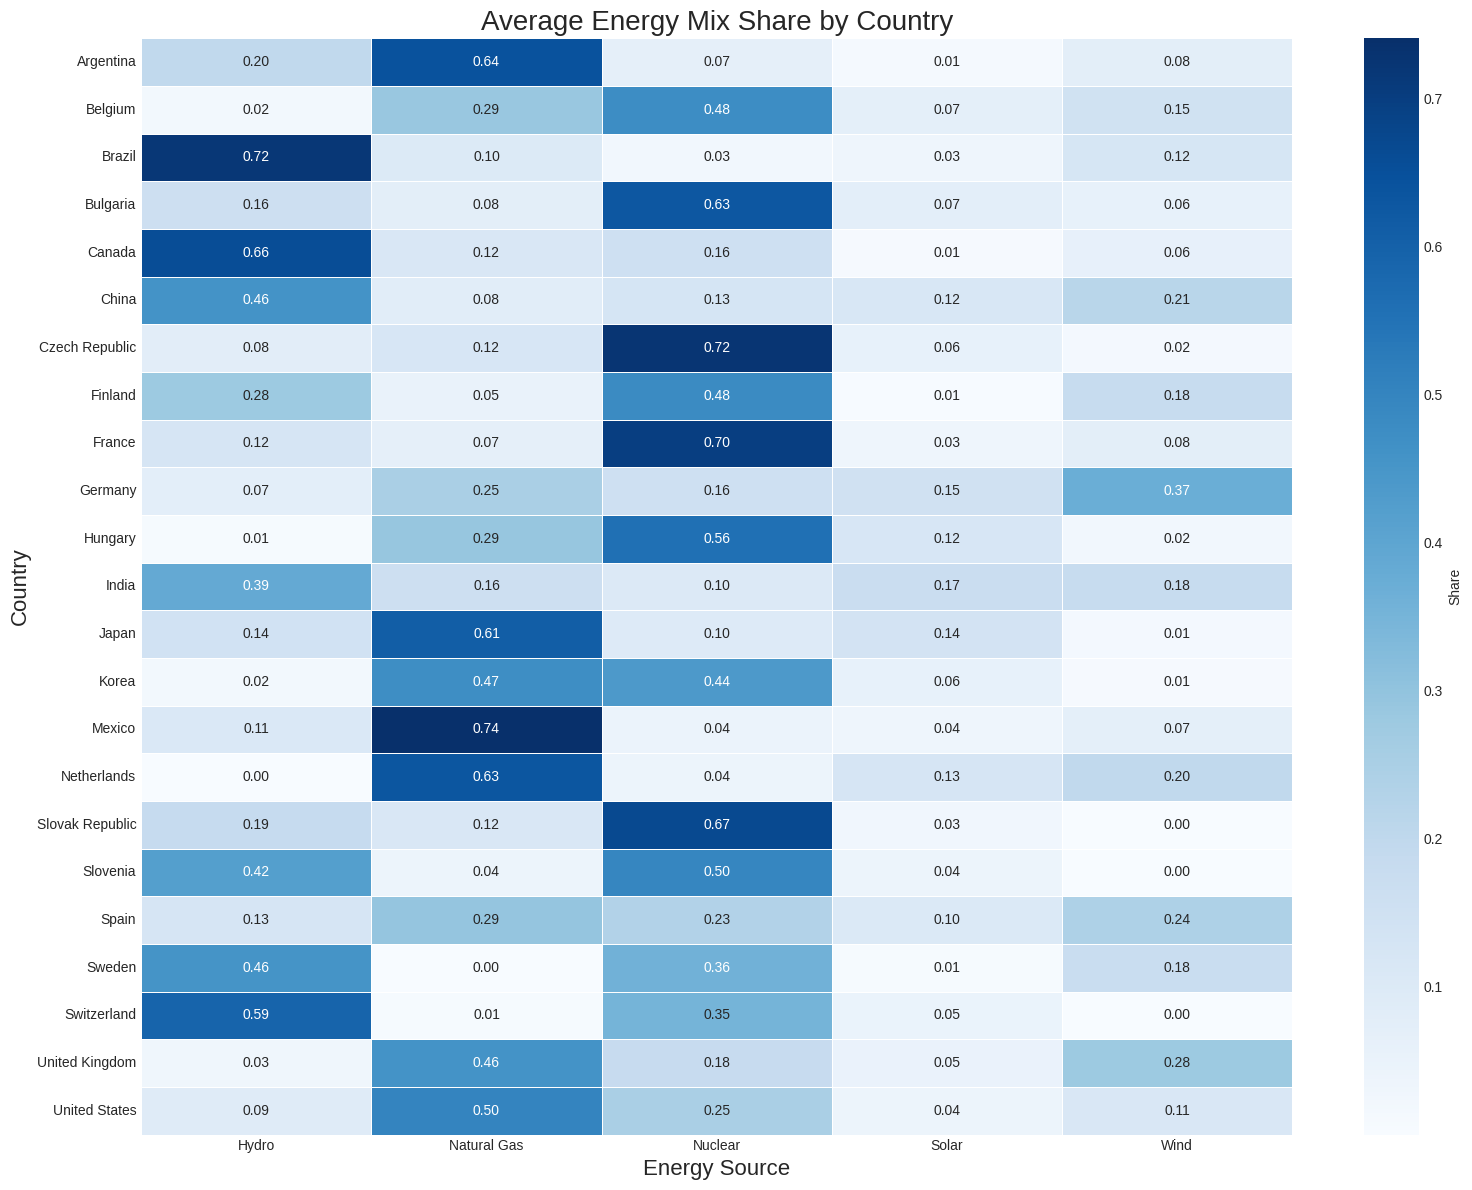

In [92]:
# Developed with the assistance of AI to show the unique values of the country_name, product, and value. Create a heatmap of the share of each product by country
total_by_country_product = selected_countries_2018_2023.groupby(
    ["country_name", "product"]
)["value"].sum().reset_index()

total_by_country = total_by_country_product.groupby("country_name")["value"].sum().reset_index()
total_by_country.columns = ["country_name", "total"]

merged = pd.merge(total_by_country_product, total_by_country, on="country_name")
merged["share"] = merged["value"] / merged["total"]

heatmap_data = merged.pivot(index="country_name", columns="product", values="share").fillna(0)

plt.figure(figsize=(16, 12))
ax1 = sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Blues",
                 linewidths=0.5, cbar_kws={"label": "Share"})

ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0, ha="center")
plt.title("Average Energy Mix Share by Country", fontsize=20)
plt.xlabel("Energy Source", fontsize=16)
plt.ylabel("Country", fontsize=16)
plt.tight_layout()
plt.show()

#### A better idea of which countries to include in our training and inference sets can be made from the Average energy mix share by country graph. Firstly our Training set will include countries of all regions, specifically, we will use 4 European, 3 Asian, 2 North American, and 1 South American, this seems like a good ratio from the 23 countries. Looking at the ratios of countries that use Nuclear power, we will pick the 2 higher and 2 lower ratios, while considering geographical regions. France and the Czech Republic are the two highest, and we will select this, the Czech Republic also has one of the smaller populations of our group containing 23 countries. The two lowest ratios of countries that use Nuclear power and an ideal selection are Mexico and Brazil. Both are developing countries being from North and South America, Brazil uses Hydro power, while Mexico uses Natural Gas as their dominant energy source. Dominant countries that use Solar and Wind more predominantly than other countries are Germany and Spain. Of the Asian countries, we will pick India, Japan, and South Korea, India is a developing country that shows an equal distribution of the types of energy sources they use. Meanwhile, Japan has a strong use of Natural Gas and uses Hydro and Solar at a reasonable level. South Korea is a developed country, typically known to be technologically advanced, they show a strong use of Nuclear and Natural Gas. Finally, we have one more North American country, we will use the United States, as they are a developed economy that has a high population, like India.

#### In summary our Training model will consist of the following countries: France, Czech Republic, Brazil, Mexico, Germany, Spain, India, Japan, South Korea, United States.

#### The Testing/Inference countries will use countries from the following: 2 Europe, 1 Asia, and 1 South America, 1 North America. We will choose a country that has a smaller population, Sweden looks ideal as they have a decent usage of Nuclear. Next, we will use a developing country, such as China. China also has a very large population and will be a good country for inference as our training model has India and the United States, two countries that have a similar high population. Canada mainly uses Hydro as its energy source and has produced a reasonable level of Nuclear power, and is from North America. One of the higher uses of Natural Gas as their power source is Argentina, they have a limited use of Nuclear power, and will be interesting to see how well our model infers, they are also a developing country in South America. Finally, the last European country we will use is the United Kingdom. They use Natural Gas as their main energy source, however use both Nuclear and produce one of the higher amounts of energy from Wind.

#### In summary the countries we will test our model on are: Sweden, China, Canada, Argentina, United Kingdom.

In [93]:
# Developed with the assistance of AI to create the final countries for training and testing
final_countries = [
    'Argentina', 'Brazil', 'Canada', 'China', 'Czech Republic', 'France', 'Germany', 'India', 'Japan', 'Korea', 'Mexico', 'Spain', 'Sweden',
    'United Kingdom', 'United States']

final_global_electricity_production_data  = selected_countries_2018_2023[
    selected_countries_2018_2023['country_name'].isin(final_countries)]

final_global_electricity_production_data.to_csv("final_global_electricity_production_data.csv", index=False)

In [94]:
dataset_path = ("final_global_electricity_production_data.csv")
final_electricity_product = load_data(dataset_path)

In [95]:
# Developed with the assistance of AI to show the unique values of the country_name and product. Pivot the final_electricity_product dataset by country_name and date. Drop any rows with NaN values
final_electricity_product["date"] = pd.to_datetime(final_electricity_product["date"])

pivot_final_electricity_product = final_electricity_product.pivot_table(index=["country_name", "date"], columns="product", values="value").reset_index()

pivot_final_electricity_product = pivot_final_electricity_product.sort_values(by=["country_name", "date"]).dropna()


#### The final_electricity_products will be pivoted with columns for Nuclear, Hydro, Natural Gas, Solar, and Wind. This will then be organised based on countries and date. This will make it easier for us to use the dataset for our workflow.

#### It was noticed that Germany in 2023 had phased out Nuclear production on 03/01/2023, these are null values, and was dropped.

In [96]:
# Developed with the assistance of AI to check if each country has all the selected products. Create the sequence length for the training and testing data. Set the target year to 2023. Create empty lists for x and y. Select the products of interest. Create sequences of length seq_length. Convert x and y to numpy arrays
def train_test_sequence(pivot, countries, seq_length = 60, target_year = 2023):
    """Function train_test_sequence creates a train and test sequence

        Arguments:
            pivot {dict} -- Dictionary of pivot data
            countries {list} -- List of countries
            seq_length {int} -- Length of sequence

        Returns:
            np.array -- Train and test sequence
    """
    x, y = [], []
    for country in countries:
        country_data = pivot[pivot["country_name"] == country].sort_values(by="date")
        dates = country_data["date"].values
        values = country_data[selected_products].values

        for i in range(len(values) - seq_length):
            target_date = pd.to_datetime(dates[i + seq_length])
            if target_date.year == target_year:
                x.append(values[i:i + seq_length])
                y.append(values[i + seq_length][selected_products.index("Nuclear")])
    return np.array(x), np.array(y)


#### A sequence length will be created for both the train and test splits, with the sequence length being 5 years, which equals 60 months. We will further split the train and test into x train, y train, x test y test. The y refers to the Nuclear energy we are predicting, while the x is the 4 other energy sources (Hydro, Natural Gas, Solar, and Wind).

In [97]:
# The selected products for the model
selected_products = ["Nuclear", "Hydro", "Natural Gas", "Solar", "Wind"]

# The countries for training and testing
training_countries = ["France", "Czech Republic", "Brazil", "Mexico", "Germany", "Spain", "India", "Japan", "Korea", "United States"]

# The countries for testing
test_countries = ["Sweden", "China", "Canada", "Argentina", "United Kingdom"]

# Create the train and test sequences
x_train, y_train = train_test_sequence(pivot_final_electricity_product, training_countries)
x_test, y_test = train_test_sequence(pivot_final_electricity_product, test_countries)


In [98]:
# Developed with the assistance of AI to shows the shape of the x train Reshape the x train. Scales the x train. Creates a StandardScaler. Shows the shape of the x test. Reshape the x test. Scales the x test. Shows the shape of the y train. Reshape the y train. Scales the y train. Creates a MinMaxScaler
x_scaler = StandardScaler()
x_train_flat = x_train.reshape(-1, x_train.shape[-1])
x_train_scaled = x_scaler.fit_transform(x_train_flat).reshape(x_train.shape)

x_test_flat = x_test.reshape(-1, x_test.shape[-1])
x_test_scaled = x_scaler.transform(x_test_flat).reshape(x_test.shape)

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

#### Both the x train and test will need to be normalised to the same scale. I have used the StandardScaler for the x train and x test, as the different energy sources are on different scales (e.g. Solar GWh is considerably less than Natural Gas GWh. The StandardScaler centers each of the energy sources closer to a mean of 0, this will help our RNN by allowing all energy sources to contribute equally. Meanwhile, for the y train and y test, we have used a different type of scaler called MiniMaxScaler. This will standardise our y train and y test to a 0-1 range, this is important as we want to keep the relative spacing and shape of the Nuclear values. I used the StandardScaler for the y train and y test, however, this resulted in negative values for the prediction of Nuclear GWh. By standardising our training and testing sequences, this will improve the performance and stability of our Recurrent Neural Network by ensuring that each feature contributes equally.

In [99]:
# Developed with the assistance of AI to split the x train and y train into a train and validation set with a ratio of 80:20. Create the train, validation, and test datasets with a batch size of 4
x_tr, x_val, y_tr, y_val = train_test_split(x_train_scaled, y_train_scaled, test_size=0.2, random_state=10)

train_dataset = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).batch(4)
validation_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(4)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(4)


#### The batch size refers to how many samples the model will see before it updates the weights, in my case I originally set the batch size to 128, this just meant I was doing one big step per epoch as I had fewer samples than a batch size of 128. Changing the batch size to 32, 18, 8, and 4 meant that it would be more granular and noiser updates, as I noticed overfitting was occurring towards the end as the validation loss started to increase while training loss was decreasing. Ultimately, a batch size of 4 provided the most optimal batch size, as other batch sizes didn't perform as well in relation to MAE loss for both the train and validation set. Using this batch size was less stable by using noiser gradients, and the training time was slower. But considering the dataset size, it allows my model to avoid the local minima, and generalise well on the test set.

In [100]:
# Shows the shape of the x train, y train, x val, y val, x test, and y test
s, t = next(iter(train_dataset))
print(f"Training: samples shape: {s.shape}, targets shape: {t.shape}")
s, t = next(iter(validation_dataset))
print(f"Validation: samples shape: {s.shape}, targets shape: {t.shape}")
s, t = next(iter(test_dataset))
print(f"Testing: samples shape: {s.shape}, targets shape: {t.shape}")

Training: samples shape: (4, 60, 5), targets shape: (4,)
Validation: samples shape: (4, 60, 5), targets shape: (4,)
Testing: samples shape: (4, 60, 5), targets shape: (4,)


#### The train set has been further split into a train and validation split, with an 80:20 ratio respectively. The random state with a value of 10 will be applied to ensure reproducibility of the split. By creating our datasets, we need to ensure that they have the correct shape. They should all have sample shape `(batch_size, sequence_length, prediction_offset)` and target shape (batch_size).

#### I have compared 3 Recurrent Neural Network types: Single-layer LSTM with 16 units, Three-layer LSTM with 16 units per layer, Three-layer GRU with 16 units per layer.
#### I have made these choices as I want to compare the different depths and types. LSTM and GRU were selected because they learn meaningful patterns from sequences or timeseries, as they retain knowledge or memory across inputs. This is important as we are using 5-year sequences for the electricity production.


In [101]:
from keras import layers

input_shape = (60, 5)
inputs = layers.Input(shape=input_shape)
x = layers.LSTM(16, recurrent_dropout=0.50)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
LSTM_model_with_dropout = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss",patience=3),
    keras.callbacks.ModelCheckpoint(filepath="lstm_dropout.keras",monitor="val_loss",save_best_only=True,),
    keras.callbacks.TensorBoard(log_dir="log_dir_LSTM_dropout",)]

LSTM_model_with_dropout.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

#### I wanted to start with a baseline reading of a simple model for the prediction of Nuclear electricity production, which consisted of  single-layer LSTM with 16 units. The input shape of 60,5 shows the sequence length of 60 months, followed by the 5 energy sources. The LSTM layer is ideal for sequence data, with the choice of 16 units being a balance between the capturing patterns and the risk of overfitting. To help regularise the model and reduce overfitting, I have used a 50% recurrent dropout to the hidden layer, followed by a 50% dropout layer after the output. This was due to experimentation as lower values of dropout resulted in slight overfitting.

#### The final layer is a dense layer with a single unit that predicts the GWh of Nuclear production, there was no activation function used here, however, it was experimented with the relu activation function. This did not make much of a difference, therefore I decided to let the model learn a continuous output.

#### I used the rmsprop optimizer, which performs well on RNN tasks. The loss function uses a mean squared error, while it is being monitored by the mean absolute error. patience was set at 3 for the model checkpoint and to ensure overfitting does not occur.

In [102]:
%reload_ext tensorboard
%tensorboard --logdir "log_dir_LSTM_dropout"

Reusing TensorBoard on port 6006 (pid 189569), started 1:21:28 ago. (Use '!kill 189569' to kill it.)

In [103]:
LSTM_model_with_dropout_history = LSTM_model_with_dropout.fit(train_dataset, validation_data=validation_dataset, epochs=20, callbacks=callbacks)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - loss: 0.3790 - mae: 0.4612 - val_loss: 0.1505 - val_mae: 0.3208
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.2225 - mae: 0.3496 - val_loss: 0.1206 - val_mae: 0.2922
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.3661 - mae: 0.4858 - val_loss: 0.0775 - val_mae: 0.2266
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.1966 - mae: 0.3244 - val_loss: 0.0583 - val_mae: 0.1996
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.1585 - mae: 0.3006 - val_loss: 0.0460 - val_mae: 0.1747
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.1459 - mae: 0.2831 - val_loss: 0.0334 - val_mae: 0.1499
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.1689 - mae: 0.2993 - val_loss: 0.0269 - val_mae: 0.1279
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.1351 - mae: 0.2593 - val_loss: 0.0181 - val_mae: 0.1068
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - lo

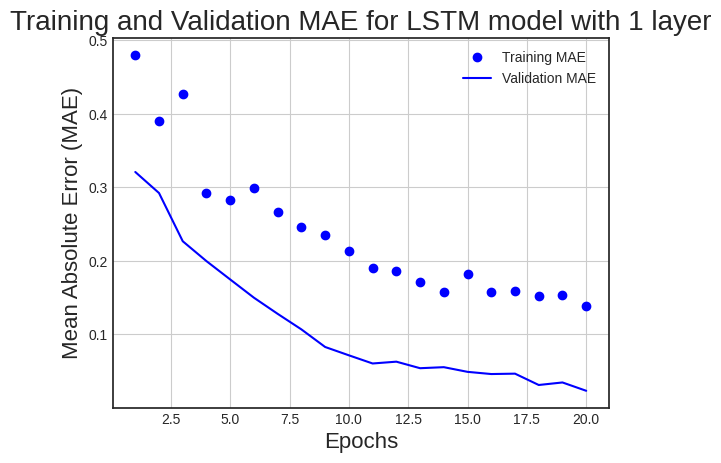

In [104]:
loss = LSTM_model_with_dropout_history.history["mae"]
val_loss = LSTM_model_with_dropout_history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.grid(True)
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE for LSTM model with 1 layer", fontsize=20)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Mean Absolute Error (MAE)", fontsize=16)
plt.legend()
plt.show()

#### From the Training and Validation MAE for LSTM model with 1 layer graph, the model has learned quickly after a few epochs at the start. Could be signs of overfitting from epoch 8 to 9 as the validation MAE increases while training loss decreases. This model has learned quite well, showing good generalisation.

In [105]:
from keras import layers

input_shape = (60, 5)
inputs = layers.Input(shape=input_shape)
x = layers.LSTM(16, recurrent_dropout=0.75, return_sequences=True)(inputs)
x = layers.LSTM(16, recurrent_dropout=0.75, return_sequences=True)(x)
x = layers.LSTM(16, recurrent_dropout=0.75)(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(1)(x)
LSTM_model_with_dropout_3l = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss",patience=3),
    keras.callbacks.ModelCheckpoint(filepath="lstm_dropout_2l.keras",monitor="val_loss",save_best_only=True,),
    keras.callbacks.TensorBoard(log_dir="log_dir_LSTM_dropout_2l",)]

LSTM_model_with_dropout_3l.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

#### The LSTM model with 3 layers stacks 3 layers, each with 16 units.The input shape of 60,5 shows the sequence length of 60 months, followed by the 5 energy sources. The use of these layers is to capture more complex patterns in the production of different types of energy sources. The first two layers has the return_sequences=True, this is to allow the output of each layer to pass to the next layer. This is important for layered RNN models, as it retains important temporal information.

#### I used 16 units per layer, as I conducted previous testing on varying units ranging from 128 to 32. This resulted in slightly worse performance among the validation mae, the other issue was training time took longer as I used larger units. I experimented with the depth of layers from 2-5, I realised more than 3 layers incurred more overfitting, and slightly worse validation MAE.

#### The recurrent dropout rate of 0.75 to each LSTM layer was applied, although this is considered quite high regularisation, it produced the lowest mae for both training and test after several iterations. After the final LSTM layer, a further 30% dropout layer was applied to reduce overfitting.

#### I used the rmsprop optimizer, which performs well on RNN tasks. The loss function uses a mean squared error, while it is being monitored by the mean absolute error. patience was set at 3 for the model checkpoint and to ensure overfitting does not occur.

In [106]:
%reload_ext tensorboard
%tensorboard --logdir "log_dir_LSTM_dropout_2l"

Reusing TensorBoard on port 6007 (pid 191190), started 1:21:21 ago. (Use '!kill 191190' to kill it.)

In [107]:
LSTM_model_with_dropout_2l_history = LSTM_model_with_dropout_3l.fit(train_dataset, validation_data=validation_dataset, epochs=20, callbacks=callbacks)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step - loss: 0.1785 - mae: 0.3203 - val_loss: 0.0277 - val_mae: 0.1075
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - loss: 0.1287 - mae: 0.2545 - val_loss: 0.0189 - val_mae: 0.0943
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 284ms/step - loss: 0.0850 - mae: 0.2200 - val_loss: 0.0133 - val_mae: 0.0885
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - loss: 0.0751 - mae: 0.2001 - val_loss: 0.0097 - val_mae: 0.0773
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - loss: 0.0449 - mae: 0.1649 - val_loss: 0.0071 - val_mae: 0.0673
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 285ms/step - loss: 0.0387 - mae: 0.1403 - val_loss: 0.0058 - val_mae: 0.0645
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - loss: 0.0195 - mae: 0.1036 - val_loss: 0.0063 - val_mae: 0.0655
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - loss: 0.0413 - mae: 0.1399 - val_loss: 0.0057 - val_mae: 0.0650
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 278ms/step - l

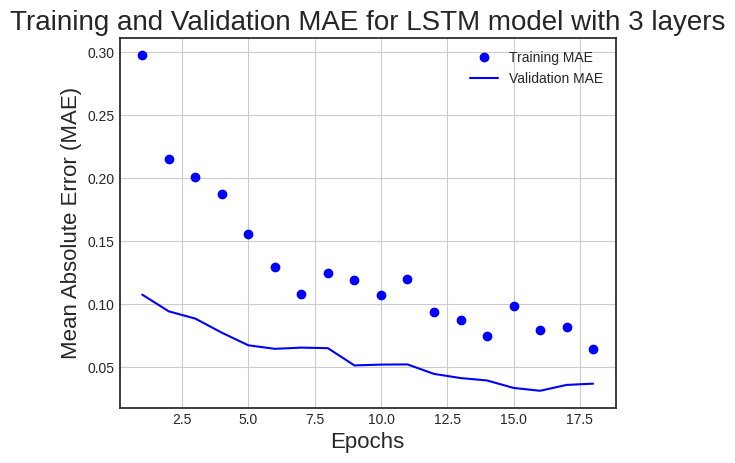

In [108]:
loss = LSTM_model_with_dropout_2l_history.history["mae"]
val_loss = LSTM_model_with_dropout_2l_history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.grid(True)
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE for LSTM model with 3 layers", fontsize=20)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Mean Absolute Error (MAE)", fontsize=16)
plt.legend()
plt.show()

#### From the Training and Validation MAE for the LSTM model with 3 layer graph, both the training MAE and validation MAE are continuing to decrease, which suggests that this model has learned and generalised well. From epoch 5 onwards it seems like the model may be overfitting as validation MAE is increasing while training loss is decreasing. Compared to the single-layer LSTM, the 3-layer LSTM model seems to be learning more patterns, the extra layer has reduced the validation MAE significantly at the start, and after several iterations, both the training and validation MAE were lower compared to the single-layer LSTM.

In [109]:
from keras import layers

input_shape = (60, 5)
inputs = layers.Input(shape=input_shape)
x = layers.GRU(16, recurrent_dropout=0.75, return_sequences=True)(inputs)
x = layers.GRU(16, recurrent_dropout=0.75, return_sequences=True)(x)
x = layers.GRU(16, recurrent_dropout=0.75)(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1)(x)
GRU_model_with_dropout_3l = keras.Model(inputs=inputs, outputs=outputs)

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss",patience=3),
    keras.callbacks.ModelCheckpoint(filepath="gru_dropout_2l.keras",monitor="val_loss",save_best_only=True,),
    keras.callbacks.TensorBoard(log_dir="log_dir_GRU_dropout_2l",)]

GRU_model_with_dropout_3l.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

#### Three-layer Gated Recurrent Unit (GRU) with 16 units per layer is an alternative to the LSTM. GRU are simpler and efficient while capturing long-term patterns in sequence data. As same as above with LSTM, I constructed a 3-layer GRU with 16 units to provide a comparison between the two types.

#### As similar to above, we have returned the sequences of each layer to the next except for the last layer. I have also applied the same recurrent dropout of 0.75. Other parameters were kept the same as above as I did not experiment too greatly with this and used the same valus to give a true comparison of the two types of models, maybe if I had tuned this model like above I would have found a better model.

In [110]:
%reload_ext tensorboard
%tensorboard --logdir "log_dir_GRU_dropout_2l"

Reusing TensorBoard on port 6008 (pid 192200), started 1:21:58 ago. (Use '!kill 192200' to kill it.)

In [111]:
GRU_model_with_dropout_2l_history = GRU_model_with_dropout_3l.fit(train_dataset, validation_data=validation_dataset, epochs=20, callbacks=callbacks)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 271ms/step - loss: 0.2802 - mae: 0.3572 - val_loss: 0.0137 - val_mae: 0.0689
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - loss: 0.1049 - mae: 0.2318 - val_loss: 0.0090 - val_mae: 0.0616
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - loss: 0.0727 - mae: 0.1957 - val_loss: 0.0063 - val_mae: 0.0622
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - loss: 0.0759 - mae: 0.1828 - val_loss: 0.0044 - val_mae: 0.0514
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 254ms/step - loss: 0.0710 - mae: 0.1940 - val_loss: 0.0036 - val_mae: 0.0503
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 253ms/step - loss: 0.0305 - mae: 0.1409 - val_loss: 0.0051 - val_mae: 0.0620
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - loss: 0.0539 - mae: 0.1591 - val_loss: 0.0035 - val_mae: 0.0494
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - loss: 0.0325 - mae: 0.1352 - val_loss: 0.0047 - val_mae: 0.0570
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 253ms/step - lo

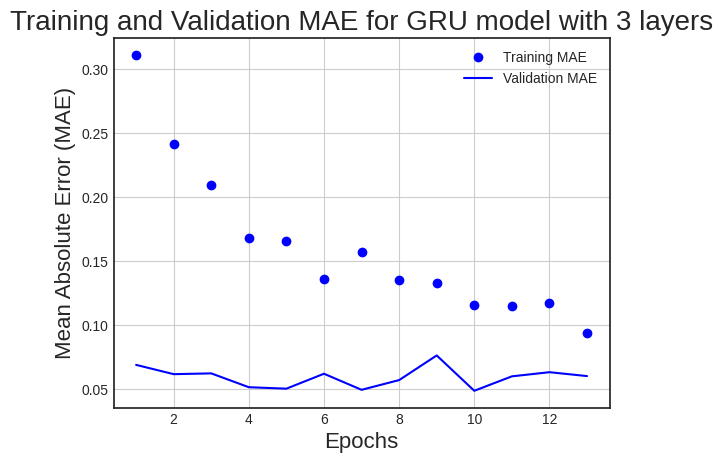

In [112]:
loss = GRU_model_with_dropout_2l_history.history["mae"]
val_loss = GRU_model_with_dropout_2l_history.history["val_mae"]

epochs = range(1, len(loss) + 1)
plt.figure()
plt.grid(True)
plt.plot(epochs, loss, "bo", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and Validation MAE for GRU model with 3 layers", fontsize=20)
plt.xlabel("Epochs", fontsize=16)
plt.ylabel("Mean Absolute Error (MAE)", fontsize=16)
plt.legend()
plt.show()

#### From the Training and Validation MAE for the GRU model with 3 layer graph, both the training MAE and validation MAE continue to decrease, which suggests that this model has learned and generalises well. After 9 Epochs there are signs of overfitting as the Validation MAE goes up while the Training MAE goes down. After several iterations, the GRU model with 3 layers did slightly worse than the LSTM model with 3 layers, however, both models seem quite stable and show strong convergence.

In [113]:
# Developed with the assistance of AI to evaluate the LSTM model with 3 layers on the test set and flatten the predictions. Clip the predictions to be between 0 and 1. Inverse transform the scaled predictions to get the original scale. Inverse transform the scaled y test to get the original scale. Calculate the Mean Absolute Error (MAE) on the test set
LSTM_model_2l_scaled_prediction = LSTM_model_with_dropout_3l.predict(test_dataset).flatten()

LSTM_model_2l_scaled_prediction = np.clip(LSTM_model_2l_scaled_prediction, 0, 1)

LSTM_model_2l_prediction = y_scaler.inverse_transform(LSTM_model_2l_scaled_prediction.reshape(-1, 1)).flatten()

y_test_unscaled = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()

mae_test_set = mean_absolute_error(y_test_unscaled, LSTM_model_2l_prediction)
print(f"Test set MAE: {mae_test_set:.3f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
Test set MAE: 38325.578


#### I have decided to implement the LSTM model with 3 layers, as this model produced the lowest training and validation MAE out of the other types after several iterations. The model didn't seem to overfit too much, whereas models with more than 3 layers were less stable and overfitted to the data more. I have had to use no.clip to ensure that the predictions were between 0 and 1, as the model was predicting values outside of this range. I have also used the inverse transform to get the original scale of the predictions, and then calculated the Mean Absolute Error (MAE) on the test set.

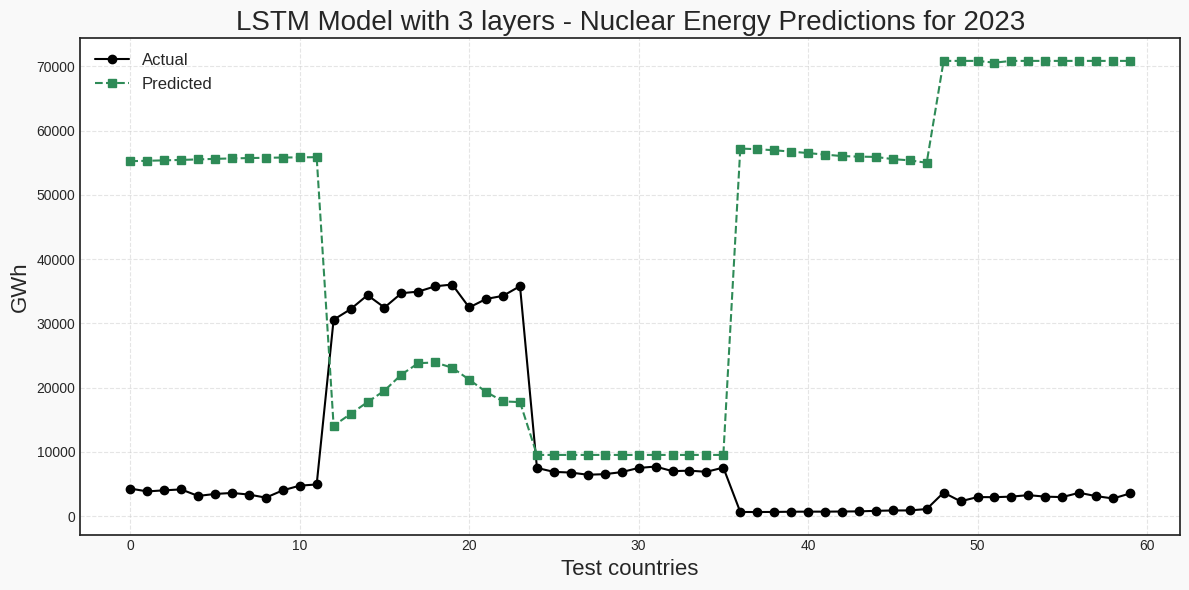

In [114]:
# Developed with the assistance of AI to plot the actual vs predicted values for the test set
plt.figure(figsize=(12, 6), facecolor="#f9f9f9")
ax = plt.gca()
ax.set_facecolor("#ffffff")
ax.plot(y_test_unscaled, "o-", label="Actual", color="black")
ax.plot(LSTM_model_2l_prediction, "s--", label="Predicted", color="seagreen")
ax.set_title("LSTM Model with 3 layers - Nuclear Energy Predictions for 2023", fontsize=20)
ax.set_xlabel("Test countries", fontsize=16)
ax.set_ylabel("GWh", fontsize=16)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

#### The LSTM model with 3 layers graph depicts the 5 test countries actual values of Nuclear energy vs our models predicted values of Nuclear energy over a 5-year history with respect to the energy production of Hydro, Natural Gas, Nuclear, Solar, and Wind. The countries are in the following order for every 12 data points, which is representative of the 12 months within 2023: Sweden, China, Canada, Argentina, United Kingdom.

#### A thorough critical analysis of how our model performed was repeated in at least 10 iterations, from this I have learned my model generalised well for countries that had an actual Nuclear energy production that was high and did extremely poorly for countries that had low Nuclear energy production. China which has an actual Nuclear production of around 30,000 for the year, was predicted close. However, towards the end of the graph which had Argentina and United Kingdom, our model predicted Nuclear Production to be similar to what the United States produced per year. For Canada, our model was somewhat close to the actual value, suggesting that the threshold for a closer prediction of the actual value of Nuclear energy production lies around here.

#### Originally our research question was "Are RNNs useful in predicting the amount of electricity of a specific type of energy (E.g. Nuclear) produced by a country". The RNN model I have used to answer this question was a 3-layer LSTM model, I have shown that my model has predicted Nuclear energy over 5 years based on the history of Hydro, Natural Gas, Nuclear, Solar, and Wind of a country. The model has predicted quite well for similar energy patterns as seen in the training data, however, it did poorly for countries with low Nuclear energy production or obscure Nuclear production trends. This can hint that my RNN model is quite sensitive to the distribution of training data.

#### In conclusion, in developing my workflow to create a RNN model, I encountered several issues along the way. Early in the workflow I had mistakingly included the prediction year 2023 data in the training set (train/test leakage). I corrected this error by modifying the train_test_sequence function to ensure the parameter included the prediction year of 2023, whereby using all other data from training.

#### The biggest source of error with my model was the training set imbalance, specifically countries with a low Nuclear energy production were under-represented. This led to very poor predictions for countries such as Sweden, Argentina, and United Kingdom. Meanwhile, countries with higher Nuclear energy production such as China and Canada performed relatively well, this is due to the similarity of training countries United States and France. If I were to extend the number of countries for training to around 15, focusing on countries with low Nuclear energy production, our model could generalise better for the test set.

#### While I did optimise several parameters (recurrent_dropout, dropout, optimizers, units), there are several other parameters that I did not. The learning rate could have been adjusted, whereby lowering it could help the model converge to a better minima. The sequence length of 60 months was set at an arbitrary value, as I considered 5 years to be an adequate history of a country's energy production for prediction. However, either training a model with fewer months or more could have helped the model recognise patterns. I set early stopping patience at 3, a higher value could have let the model learn slower, thereby improving performance.

#### The other type of model I did not explore was the bi-directional model, this would be useful if both the past and future windows within the sequence length are important.

In [115]:
from numba import cuda
cuda.select_device(0)
cuda.close()

ModuleNotFoundError: No module named 'numba'